In [75]:
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply({lambda x: ast.literal_eval(x) if pd.notna(x) else(x)})

In [76]:
df_DA_india = df [(df['job_title_short'] == 'Data Analyst') & (df ['job_country'] == 'India')].copy()
df_DA_india = df_DA_india.dropna(subset=['salary_year_avg'])
df_DA_india_exploded = df_DA_india.explode('job_skills')
df_DA_india_exploded [['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


In [77]:
df_DA_skills = df_DA_india_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False).head(10)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

In [78]:
df_DA_skills

,skill_count,median_salary
job_skills,,
sql,46,96050.0
excel,39,98500.0
python,36,96050.0
tableau,20,108087.5
r,18,79200.0
power bi,17,111175.0
azure,15,93600.0
aws,12,79200.0
oracle,11,79200.0


In [79]:
DA_job_count = len(df_DA_india)

df_DA_skills['skill_percentage'] = (df_DA_skills['skill_count'] / DA_job_count) * 100

df_DA_skills    

,skill_count,median_salary,skill_percentage
job_skills,,,
sql,46,96050.0,48.936170
excel,39,98500.0,41.489362
python,36,96050.0,38.297872
tableau,20,108087.5,21.276596
r,18,79200.0,19.148936
power bi,17,111175.0,18.085106
azure,15,93600.0,15.957447
aws,12,79200.0,12.765957
oracle,11,79200.0,11.702128


In [80]:
skill_percent = 5
df_DA_skills_high_demand = df_DA_skills [df_DA_skills ['skill_percentage'] > skill_percent]
df_DA_skills_high_demand

,skill_count,median_salary,skill_percentage
job_skills,,,
sql,46,96050.0,48.936170
excel,39,98500.0,41.489362
python,36,96050.0,38.297872
tableau,20,108087.5,21.276596
r,18,79200.0,19.148936
power bi,17,111175.0,18.085106
azure,15,93600.0,15.957447
aws,12,79200.0,12.765957
oracle,11,79200.0,11.702128


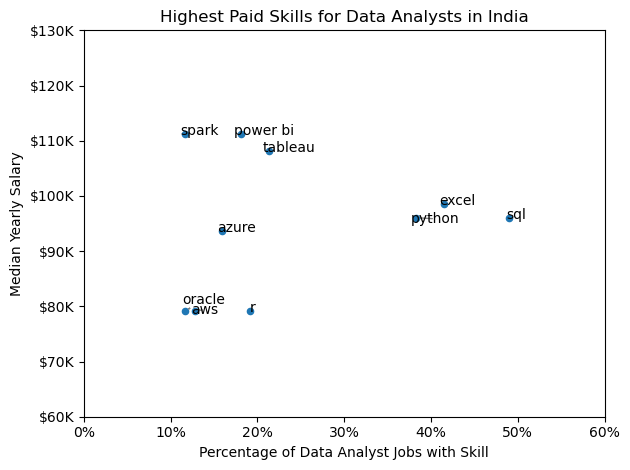

In [81]:
from adjustText import adjust_text
df_DA_skills.plot(kind='scatter', x='skill_percentage', y='median_salary')
# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills.index):
    texts.append(plt.text(df_DA_skills['skill_percentage'].iloc[i], df_DA_skills['median_salary'].iloc[i], txt))
#Adjust text to avoid over lap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
#Set axis labels, title, and legend
plt.xlabel('Percentage of Data Analyst Jobs with Skill')
plt.ylabel('Median Yearly Salary')
plt.title('Highest Paid Skills for Data Analysts in India')
plt.ylim(60000, 130000)  # Set the same x-axis limits as the second plot
plt.xlim(0, 60)  # Set the same x-axis limits as the second plot

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

#Adjust layout and display plot
plt.tight_layout()
plt.show()

In [82]:
df['job_type_skills']

0                                                      None
1         {'analyst_tools': ['power bi', 'tableau'], 'pr...
2         {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3         {'cloud': ['aws'], 'libraries': ['tensorflow',...
4         {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
                                ...                        
785736    {'os': ['linux', 'unix'], 'other': ['kubernete...
785737    {'analyst_tools': ['sas', 'excel'], 'programmi...
785738           {'analyst_tools': ['powerpoint', 'excel']}
785739    {'cloud': ['aws', 'snowflake', 'azure', 'redsh...
785740                {'cloud': ['aws'], 'other': ['flow']}
Name: job_type_skills, Length: 785741, dtype: object

In [83]:
df_technology = df['job_type_skills'].copy()
df_technology = df_technology.drop_duplicates()

#remove NaN values
df_technology = df_technology.dropna()
#combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict: #if key already exists in technology_dict, add value to existing value
            technology_dict [key] += value
        else:
        # if key does not exist in technology_dict, add key and value
            technology_dict [key] = value

#remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['word',
  'spreadsheet',
  'sharepoint',
  'ssis',
  'powerpoint',
  'power bi',
  'datarobot',
  'msaccess',
  'ssrs',
  'sheets',
  'looker',
  'powerbi',
  'visio',
  'ms access',
  'dax',
  'sas',
  'spss',
  'sap',
  'outlook',
  'excel',
  'cognos',
  'microstrategy',
  'alteryx',
  'qlik',
  'esquisse',
  'tableau',
  'splunk',
  'nuix'],
 'programming': ['r',
  'apl',
  'ruby',
  'visualbasic',
  'haskell',
  'javascript',
  'python',
  'c',
  'pascal',
  't-sql',
  'java',
  'golang',
  'objective-c',
  'vb.net',
  'fortran',
  'groovy',
  'swift',
  'sql',
  'kotlin',
  'c#',
  'php',
  'mongodb',
  'erlang',
  'ocaml',
  'shell',
  'assembly',
  'clojure',
  'html',
  'lisp',
  'sas',
  'vba',
  'f#',
  'typescript',
  'cobol',
  'lua',
  'bash',
  'go',
  'rust',
  'dart',
  'elixir',
  'c++',
  'powershell',
  'julia',
  'matlab',
  'delphi',
  'solidity',
  'nosql',
  'sass',
  'visual basic',
  'no-sql',
  'scala',
  'perl',
  'crystal',
  'mongo',
  '

In [84]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['Technology', 'Skills'])

In [85]:
df_technology = df_technology.explode('Skills')

df_technology

,Technology,Skills
0,analyst_tools,word
0,analyst_tools,spreadsheet
0,analyst_tools,sharepoint
0,analyst_tools,ssis
0,analyst_tools,powerpoint
...,...,...
9,sync,mattermost
9,sync,webex
9,sync,rocketchat
9,sync,twilio


In [88]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='Skills')

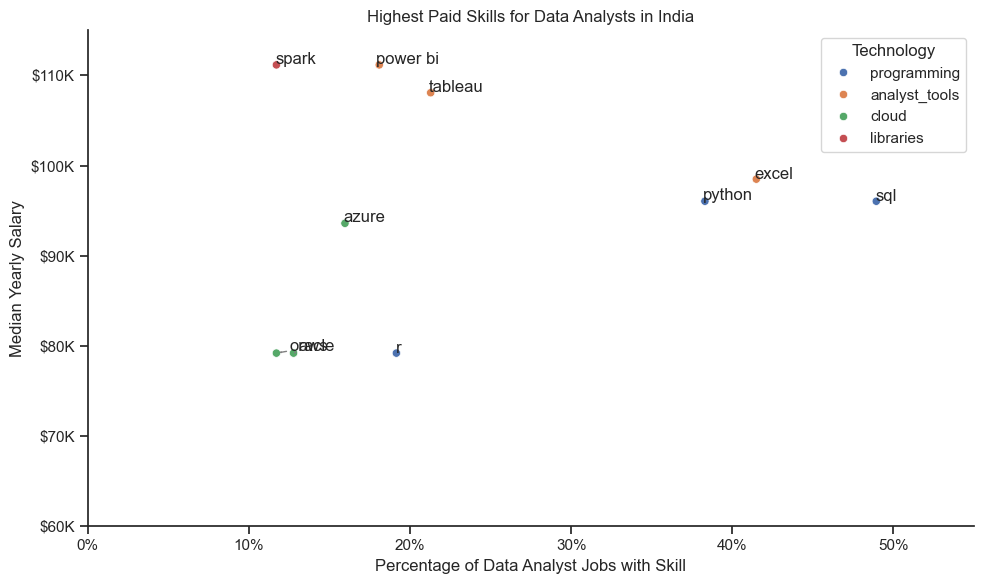

In [102]:
from adjustText import adjust_text
#df_DA_skills.plot(kind='scatter', x='skill_percentage', y='median_salary')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='skill_percentage',
    y='median_salary',
    hue='Technology'
    
)
sns.set_theme(style="ticks")
sns.despine()

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills.index):
    texts.append(plt.text(df_DA_skills['skill_percentage'].iloc[i], df_DA_skills['median_salary'].iloc[i], txt))
#Adjust text to avoid over lap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
#Set axis labels, title, and legend
plt.xlabel('Percentage of Data Analyst Jobs with Skill')
plt.ylabel('Median Yearly Salary')
plt.title('Highest Paid Skills for Data Analysts in India')
plt.ylim(60000, 115000)  # Set the same x-axis limits as the second plot
plt.xlim(0, 55)  # Set the same x-axis limits as the second plot

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

#Adjust layout and display plot
plt.tight_layout()
plt.show()